In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import torch 
from src.config import CHECKPOINT_DIR
import matplotlib.pyplot as plt

In [7]:
checkpoint_path = CHECKPOINT_DIR / "baseline_cnn_SepConvLSTM" / "v1.pt"
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

In [5]:
checkpoint_path = CHECKPOINT_DIR / "baseline_cnn_lstm" / "baseline_cnn_lstm_v1.pt"
checkpoint = torch.load(checkpoint_path)

In [8]:
print(checkpoint["config"])

{'num_frames': 32, 'batch_size': 2, 'hidden_channels': 128, 'learning_rate': 5e-05, 'epochs': 50, 'dropout': 0.4, 'augment': True}


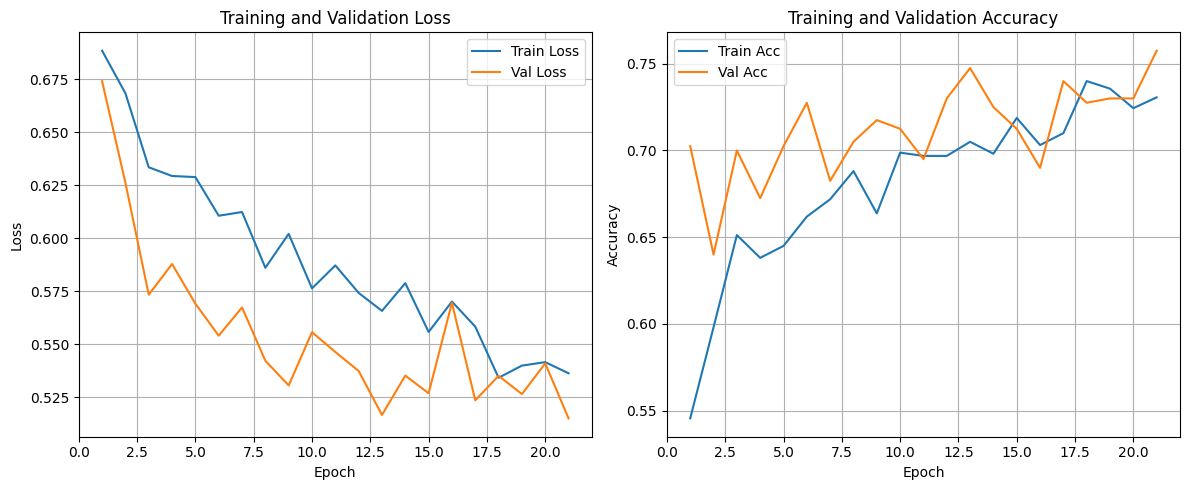

In [9]:
history = checkpoint["history"]
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
history["train_acc"][-1], history["val_acc"][-1]

(0.730625, 0.7575)

In [11]:
print("final training accuracy:", history["train_acc"][-1])
print("final validation accuracy:", history["val_acc"][-1])
print("\nfinal training loss:", history["train_loss"][-1])
print("final validation loss:", history["val_loss"][-1])

final training accuracy: 0.730625
final validation accuracy: 0.7575

final training loss: 0.536296090874821
final validation loss: 0.5150493974238635
